          order_id order_date ship_date       ship_mode    customer_name  \
0     AG-2011-2040   1/1/2011  6/1/2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   
2     HU-2011-1220   1/1/2011  5/1/2011    Second Class    Annie Thurman   
3  IT-2011-3647632   1/1/2011  5/1/2011    Second Class     Eugene Moren   
4    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name sales quantity  \
0  Office Supplies      Storage          Tenex Lockers,

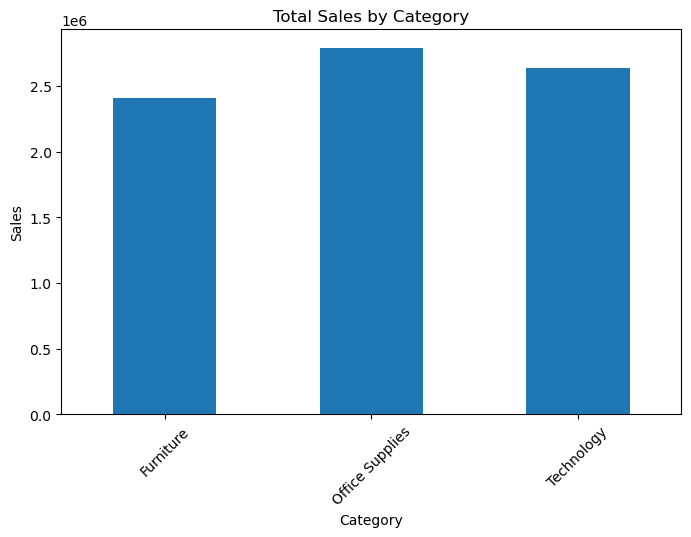

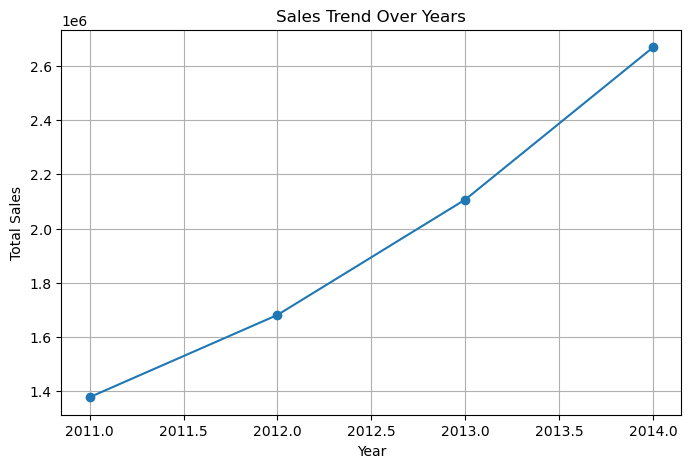

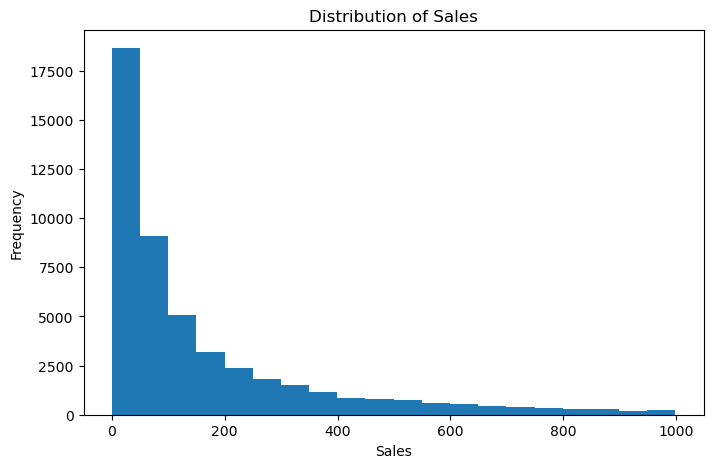

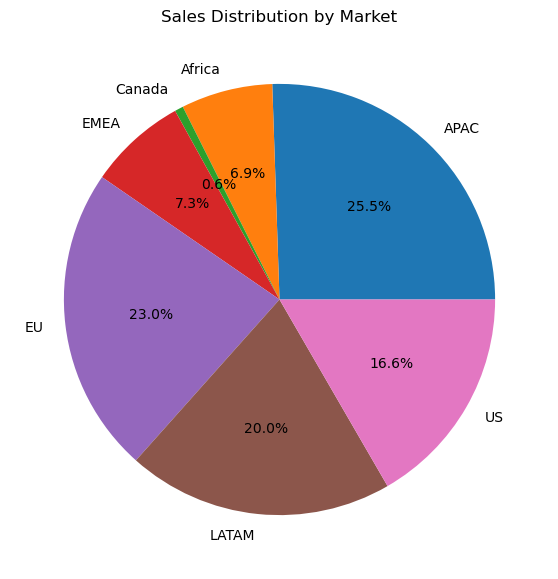

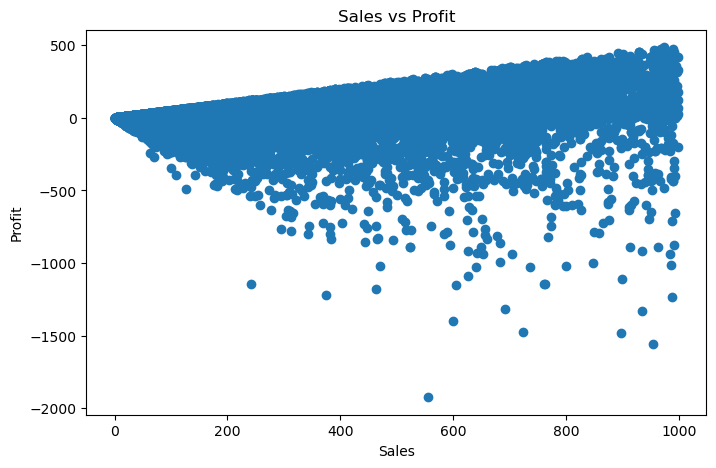

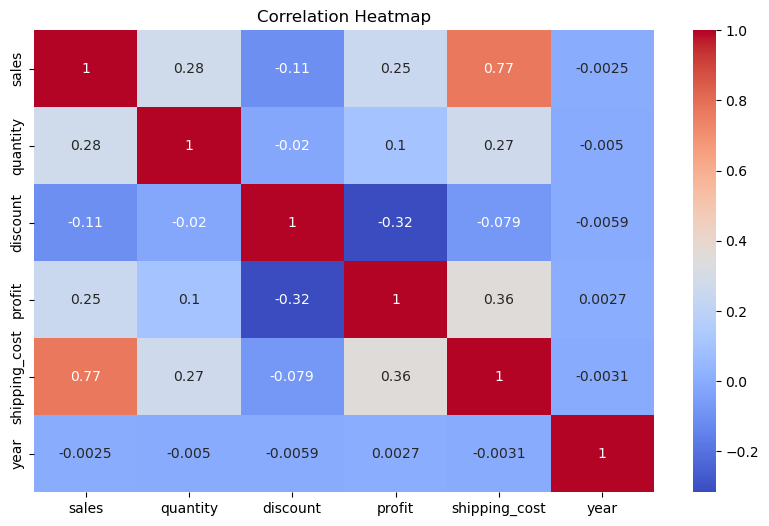

Data visualization completed successfully.
Charts and graphs were created to identify trends, patterns, and relationships in the dataset.


In [5]:
# TASK 04: Data Visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Dataset
df = pd.read_csv("SuperStoreOrders.csv")

# Displaying First 5 Rows
print(df.head())

df["sales"] = pd.to_numeric(df["sales"], errors='coerce')
df["profit"] = pd.to_numeric(df["profit"], errors='coerce')
df["quantity"] = pd.to_numeric(df["quantity"], errors='coerce')

# Bar Chart
category_sales = df.groupby("category")["sales"].sum()
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# Line Chart
yearly_sales = df.groupby("year")["sales"].sum()

plt.figure(figsize=(8,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')
plt.title("Sales Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

# Histogram
plt.figure(figsize=(8,5))
plt.hist(df["sales"], bins=20)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# Pie Chart
market_sales = df.groupby("market")["sales"].sum()
plt.figure(figsize=(7,7))
market_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Distribution by Market")
plt.ylabel("")
plt.show()

# Scatter Plot
plt.figure(figsize=(8,5))
plt.scatter(df["sales"], df["profit"])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

# Heatmap
numeric_data = df.select_dtypes(include=['number'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Key Insights
print("Data visualization completed successfully.")
print("Charts and graphs were created to identify trends, patterns, and relationships in the dataset.")

Model Evaluation
------------------
Mean Absolute Error: 77.51983149898221
R2 Score: 0.61303815022625


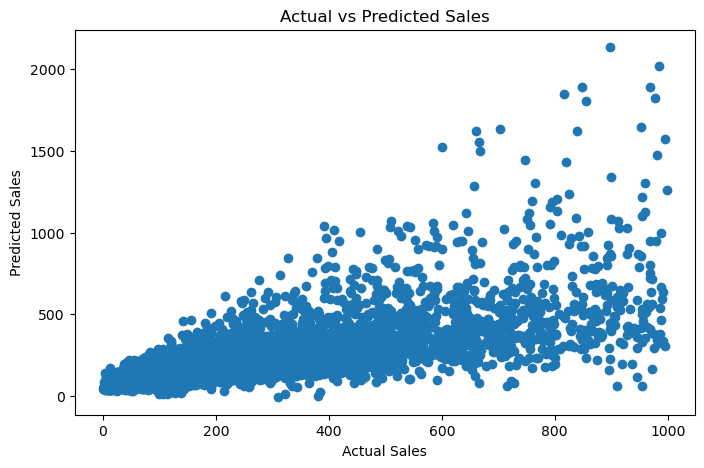


Key Insights:
- Profit and quantity positively influence sales.
- Discount can reduce profitability if too high.
- Shipping cost impacts overall sales performance.
- The model can estimate sales using historical data.


In [6]:
# TASK 05: Predictive Model using Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

df["sales"] = pd.to_numeric(df["sales"], errors='coerce')
df["profit"] = pd.to_numeric(df["profit"], errors='coerce')
df["quantity"] = pd.to_numeric(df["quantity"], errors='coerce')
df["discount"] = pd.to_numeric(df["discount"], errors='coerce')
df["shipping_cost"] = pd.to_numeric(df["shipping_cost"], errors='coerce')

df = df.dropna()

# Selecting Features and Target Variable
X = df[["profit", "quantity", "discount", "shipping_cost"]]
y = df["sales"]

# Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Applying Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Making Predictions
y_pred = model.predict(X_test)

# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("------------------")
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

# Actual vs Predicted Data
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

# Key Insights
print("\nKey Insights:")
print("- Profit and quantity positively influence sales.")
print("- Discount can reduce profitability if too high.")
print("- Shipping cost impacts overall sales performance.")
print("- The model can estimate sales using historical data.")